In [1]:
!pip install torch torchvision torchaudio scipy tqdm matplotlib pandas -q

In [2]:
from pathlib import Path
import pickle

USE_SAVED_HISTORY = True
SAVE_DIR = Path("saved_models")
HISTORY_FILE = SAVE_DIR / "training_history.pkl"

if USE_SAVED_HISTORY:
    if not HISTORY_FILE.exists():
        raise FileNotFoundError(
            f"未找到 {HISTORY_FILE.resolve()}。请先训练并在项目中保存 history，"
            "或将 USE_SAVED_HISTORY 设为 False 后从头训练。"
        )
    with open(HISTORY_FILE, "rb") as f:
        history = pickle.load(f)
    m3 = history["model3"]
    train_loss_list3 = m3["train_loss"]
    train_acc_list3 = m3["train_acc"]
    test_acc_list3 = m3["test_acc"]
    epochs = history["metadata"]["epochs"]
    meta = history.get("metadata", {})
    print("已从 pickle 加载 CNN（model3）指标")
    print(f"  保存时间: {meta.get('saved_date', '未知')}")
    print(f"  epochs: {epochs}")
else:
    train_loss_list3 = train_acc_list3 = test_acc_list3 = None
    epochs = None
    print("USE_SAVED_HISTORY=False：请依次运行下方「数据 → 模型 → 训练」，再运行绘图单元。")


已从 pickle 加载 CNN（model3）指标
  保存时间: 2026-03-19 08:34:01
  epochs: 15


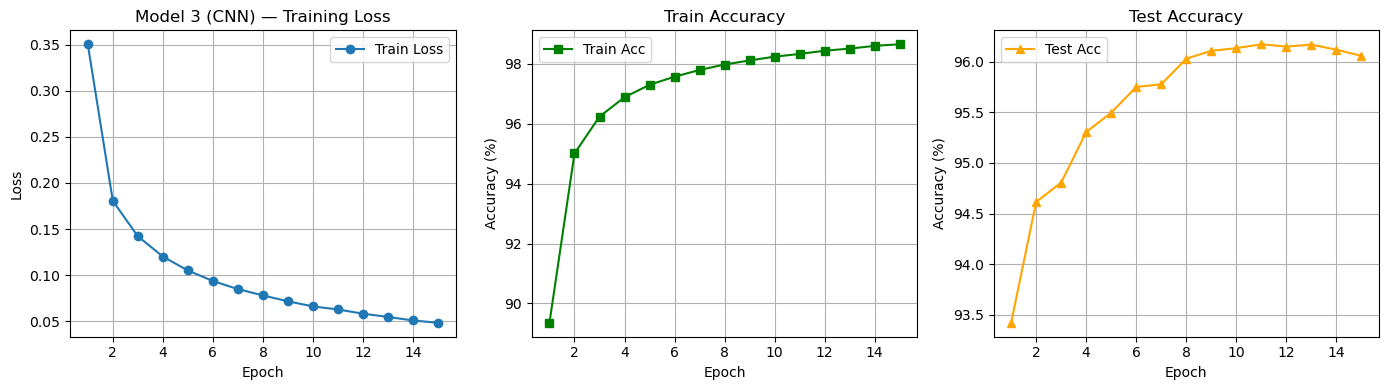

In [3]:
import matplotlib.pyplot as plt

if train_loss_list3 is None:
    raise RuntimeError(
        "没有可绘制的数据：请设置 USE_SAVED_HISTORY=True 并确保存在 training_history.pkl，"
        "或完成上方训练单元后再绘图。"
    )

n = len(train_loss_list3)
xs = range(1, n + 1)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(xs, train_loss_list3, "-o", label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 3 (CNN) — Training Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(xs, train_acc_list3, "-s", label="Train Acc", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Train Accuracy")
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(xs, test_acc_list3, "-^", label="Test Acc", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


## 1.Load the CNN Model 

In [4]:
from pathlib import Path
import pickle

USE_SAVED_RESULTS = True
SAVE_DIR = Path("saved_models")
BASELINE_HISTORY_FILE = SAVE_DIR / "training_history.pkl"
ABLATION_RESULTS_FILE = SAVE_DIR / "cnn_ablation_results.pkl"

ablation_results = {}


def normalize_loaded_result(name, train_loss, train_acc, test_acc, config=None, notes=""):
    return {
        "name": name,
        "config": config or {},
        "train_loss": list(train_loss),
        "train_acc": list(train_acc),
        "test_acc": list(test_acc),
        "epochs": len(train_loss),
        "notes": notes,
        "param_count": None,
        "final_train_loss": float(train_loss[-1]),
        "final_train_acc": float(train_acc[-1]),
        "final_test_acc": float(test_acc[-1]),
    }


if USE_SAVED_RESULTS:
    if BASELINE_HISTORY_FILE.exists():
        with open(BASELINE_HISTORY_FILE, "rb") as f:
            history = pickle.load(f)
        meta = history.get("metadata", {})
        m3 = history["model3"]
        ablation_results["Baseline CNN"] = normalize_loaded_result(
            name="Baseline CNN",
            train_loss=m3["train_loss"],
            train_acc=m3["train_acc"],
            test_acc=m3["test_acc"],
            config={
                "augmentation": "none",
                "scheduler": "none",
                "epochs": meta.get("epochs", len(m3["train_loss"])),
                "channels": (32, 64, 128),
                "first_kernel_size": 3,
                "use_gap": False,
                "dropout": 0.5,
                "weight_decay": 0.0,
            },
            notes=f"Loaded from {BASELINE_HISTORY_FILE.name}",
        )
        print(f"已加载 Baseline CNN: {meta.get('saved_date', '未知时间')} 保存")
    else:
        print("未找到 baseline history，后续可直接运行新的实验。")

    if ABLATION_RESULTS_FILE.exists():
        with open(ABLATION_RESULTS_FILE, "rb") as f:
            saved_ablation_results = pickle.load(f)
        if not isinstance(saved_ablation_results, dict):
            raise TypeError("cnn_ablation_results.pkl 的内容不是 dict，请检查保存格式。")
        ablation_results.update(saved_ablation_results)
        print(f"已加载 {len(saved_ablation_results)} 个已保存的消融实验结果。")
    else:
        print("暂未找到 cnn_ablation_results.pkl，新实验运行后会自动保存。")
else:
    print("USE_SAVED_RESULTS=False：将只在本次运行中保留实验结果。")

print("当前可用实验：", list(ablation_results.keys()))

已加载 Baseline CNN: 2026-03-19 08:34:01 保存
已加载 14 个已保存的消融实验结果。
当前可用实验： ['Baseline CNN', 'P1 - Light Augmentation', 'P1 - Color Augmentation', 'P2 - Fixed LR (15 epochs)', 'P2 - StepLR (15 epochs)', 'P2 - CosineAnnealingLR (15 epochs)', 'P2 - CosineAnnealingLR (30 epochs)', 'P3 - Deeper CNN (256 Block)', 'P3 - First Kernel 5x5', 'P3 - Global Average Pooling', 'P4 - Dropout 0.3', 'P4 - Dropout 0.5', 'P4 - Dropout 0.7', 'P4 - Weight Decay 1e-4']


## 2. 数据增强与 DataLoader

这一部分将 CNN 的第一阶段消融实验参数化：
- `none`: 仅 `ToTensor + Normalize`
- `light`: `RandomCrop + RandomRotation`
- `color`: 在 `light` 基础上加入 `ColorJitter`

只有在真正训练某个实验时，才会构建对应的 DataLoader。

In [5]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset


def get_transforms(augmentation="none"):
    normalize = transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))

    if augmentation == "none":
        train_transform = transforms.Compose([
            transforms.ToTensor(),
            normalize,
        ])
    elif augmentation == "light":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomRotation(15),
            transforms.ToTensor(),
            normalize,
        ])
    elif augmentation == "color":
        train_transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        raise ValueError(f"不支持的数据增强模式: {augmentation}")

    test_transform = transforms.Compose([
        transforms.ToTensor(),
        normalize,
    ])
    return train_transform, test_transform


def build_dataloaders(
    augmentation="none",
    batch_size=128,
    # num_workers=4,
    num_workers=0,
    root_path="./svhn_cropped",
):
    train_transform, test_transform = get_transforms(augmentation)

    train_set = torchvision.datasets.SVHN(
        root=root_path, split="train", download=False, transform=train_transform
    )
    extra_set = torchvision.datasets.SVHN(
        root=root_path, split="extra", download=False, transform=train_transform
    )
    test_set = torchvision.datasets.SVHN(
        root=root_path, split="test", download=False, transform=test_transform
    )

    full_train_set = ConcatDataset([train_set, extra_set])
    pin_memory = torch.cuda.is_available()

    train_loader = DataLoader(
        full_train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )

    return train_loader, test_loader


print("数据管线已定义：可按 augmentation=none/light/color 构建实验。")

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


数据管线已定义：可按 augmentation=none/light/color 构建实验。


## 3. 参数化 CNN 结构

这里把 CNN 改成可配置版本，便于做第三阶段和第四阶段对比：
- `channels`: 控制卷积块深度，例如 `(32, 64, 128)` 或 `(32, 64, 128, 256)`
- `first_kernel_size`: 对比首层 `3x3` 与 `5x5`
- `use_gap`: 是否用 `Global Average Pooling`
- `dropout`: 对比 `0.3 / 0.5 / 0.7`

In [6]:
import torch.nn as nn


def conv_block(in_channels, out_channels, kernel_size=3):
    padding = kernel_size // 2
    return [
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.MaxPool2d(2),
    ]


class AblationCNN(nn.Module):
    def __init__(
        self,
        channels=(32, 64, 128),
        first_kernel_size=3,
        use_gap=False,
        dropout=0.5,
    ):
        super().__init__()
        channels = tuple(channels)

        layers = []
        in_channels = 3
        for idx, out_channels in enumerate(channels):
            kernel_size = first_kernel_size if idx == 0 else 3
            layers.extend(conv_block(in_channels, out_channels, kernel_size=kernel_size))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)
        self.use_gap = use_gap

        if use_gap:
            self.classifier = nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Dropout(dropout),
                nn.Linear(channels[-1], 10),
            )
        else:
            feature_map_size = 32 // (2 ** len(channels))
            if feature_map_size < 1:
                raise ValueError("卷积块太深，特征图尺寸已小于 1。")
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(channels[-1] * feature_map_size * feature_map_size, 512),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(512, 10),
            )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


baseline_param_count = count_parameters(AblationCNN())
print(f"Baseline CNN 参数量: {baseline_param_count:,}")

Baseline CNN 参数量: 1,147,914


## 4. 训练、保存、对比与阶段化实验

下面的代码会统一处理：
- 固定 LR / `StepLR` / `CosineAnnealingLR`
- `epochs`、`weight_decay`、`dropout` 等超参
- 单个实验训练与自动保存
- 多实验汇总表
- 按阶段绘制 Loss / Train Accuracy / Test Accuracy 对比曲线

你可以直接运行已保存结果的绘图，也可以按 `PHASE_1` 到 `PHASE_4` 逐阶段追加实验。

In [7]:
import copy
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")


if "Baseline CNN" in ablation_results and ablation_results["Baseline CNN"].get("param_count") is None:
    ablation_results["Baseline CNN"]["param_count"] = count_parameters(AblationCNN())


def build_scheduler(optimizer, config):
    scheduler_name = config.get("scheduler", "none")
    if scheduler_name == "none":
        return None
    if scheduler_name == "step":
        return optim.lr_scheduler.StepLR(
            optimizer,
            step_size=config.get("step_size", 5),
            gamma=config.get("gamma", 0.5),
        )
    if scheduler_name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=config.get("epochs", 15),
            eta_min=config.get("eta_min", 1e-5),
        )
    raise ValueError(f"不支持的 scheduler: {scheduler_name}")


def save_ablation_results(results, path=ABLATION_RESULTS_FILE):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)
    print(f"实验结果已保存到: {path}")


def finalize_result(name, config, train_loss, train_acc, test_acc, param_count, lr_history):
    return {
        "name": name,
        "config": copy.deepcopy(config),
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "epochs": len(train_loss),
        "notes": config.get("notes", ""),
        "param_count": param_count,
        "lr_history": lr_history,
        "final_train_loss": float(train_loss[-1]),
        "final_train_acc": float(train_acc[-1]),
        "final_test_acc": float(test_acc[-1]),
    }


def train_one_experiment(name, config):
    config = copy.deepcopy(config)
    print(f"\n开始实验: {name}")
    print(config)

    train_loader, test_loader = build_dataloaders(
        augmentation=config.get("augmentation", "none"),
        batch_size=config.get("batch_size", 128),
        num_workers=config.get("num_workers", 4),
        root_path=config.get("root_path", "./svhn_cropped"),
    )

    model = AblationCNN(
        channels=config.get("channels", (32, 64, 128)),
        first_kernel_size=config.get("first_kernel_size", 3),
        use_gap=config.get("use_gap", False),
        dropout=config.get("dropout", 0.5),
    ).to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config.get("lr", 1e-3),
        weight_decay=config.get("weight_decay", 0.0),
    )
    scheduler = build_scheduler(optimizer, config)

    train_loss_list = []
    train_acc_list = []
    test_acc_list = []
    lr_history = []
    epochs = config.get("epochs", 15)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"{name} | Epoch {epoch + 1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        train_loss_list.append(avg_train_loss)
        train_acc_list.append(train_acc)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_acc = 100 * correct / total
        test_acc_list.append(test_acc)
        lr_history.append(optimizer.param_groups[0]["lr"])

        print(
            f"Epoch {epoch + 1:2d} | LR: {optimizer.param_groups[0]['lr']:.6f} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%"
        )

        if scheduler is not None:
            scheduler.step()
    import gc

    del train_loader, test_loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f"\n{name} 训练结束，正在写入结果...")

    result = finalize_result(
        name=name,
        config=config,
        train_loss=train_loss_list,
        train_acc=train_acc_list,
        test_acc=test_acc_list,
        param_count=count_parameters(model),
        lr_history=lr_history,
    )
    ablation_results[name] = result
    save_ablation_results(ablation_results)
    return result


def run_experiments(experiments, overwrite=False):
    completed_names = []
    for name, config in experiments.items():
        if name in ablation_results and not overwrite:
            print(f"跳过已存在实验: {name}")
        else:
            train_one_experiment(name, config)
        if name in ablation_results:
            completed_names.append(name)
    return completed_names


def summarize_results(experiment_names=None):
    if experiment_names is None:
        experiment_names = list(ablation_results.keys())

    rows = []
    for name in experiment_names:
        if name not in ablation_results:
            continue
        result = ablation_results[name]
        config = result.get("config", {})
        rows.append(
            {
                "Experiment": name,
                "Epochs": result.get("epochs", len(result["train_loss"])),
                "Final Train Loss": f"{result['final_train_loss']:.4f}",
                "Final Train Acc": f"{result['final_train_acc']:.2f}%",
                "Final Test Acc": f"{result['final_test_acc']:.2f}%",
                "Train-Test Gap": f"{result['final_train_acc'] - result['final_test_acc']:.2f}%",
                "_sort_test_acc": result["final_test_acc"],
                "Params": result.get("param_count"),
                "Aug": config.get("augmentation", "none"),
                "Scheduler": config.get("scheduler", "none"),
                "Dropout": config.get("dropout", "-"),
                "Weight Decay": config.get("weight_decay", 0.0),
                "Channels": str(config.get("channels", "-")),
                "First Kernel": config.get("first_kernel_size", "-"),
                "GAP": config.get("use_gap", False),
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(by="_sort_test_acc", ascending=False).drop(columns=["_sort_test_acc"])
    return df


def plot_experiment_group(experiment_names, title_prefix="CNN Ablation"):
    experiment_names = [name for name in experiment_names if name in ablation_results]
    if not experiment_names:
        raise ValueError("没有找到可绘制的实验名称。")

    plt.figure(figsize=(18, 4))
    metrics = [
        ("train_loss", "Train Loss", "Loss"),
        ("train_acc", "Train Accuracy", "Accuracy (%)"),
        ("test_acc", "Test Accuracy", "Accuracy (%)"),
    ]

    for subplot_idx, (metric_key, title, ylabel) in enumerate(metrics, start=1):
        plt.subplot(1, 3, subplot_idx)
        for name in experiment_names:
            result = ablation_results[name]
            xs = range(1, len(result[metric_key]) + 1)
            plt.plot(xs, result[metric_key], marker="o", linewidth=2, label=name)
        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        plt.title(f"{title_prefix} — {title}")
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_lr_history(experiment_names):
    experiment_names = [name for name in experiment_names if name in ablation_results]
    if not experiment_names:
        raise ValueError("没有找到可绘制学习率的实验名称。")

    plt.figure(figsize=(8, 4))
    for name in experiment_names:
        lr_history = ablation_results[name].get("lr_history")
        if not lr_history:
            continue
        xs = range(1, len(lr_history) + 1)
        plt.plot(xs, lr_history, marker="o", linewidth=2, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.title("Learning Rate Scheduling Comparison")
    plt.grid(True)
    plt.legend()
    plt.show()


def get_available_experiment_names(experiments):
    return [name for name in experiments.keys() if name in ablation_results]


def plot_accuracy_comparison(experiment_names, title_prefix="Phase"):
    experiment_names = [name for name in experiment_names if name in ablation_results]
    if not experiment_names:
        raise ValueError("没有找到可绘制的实验名称。")

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    for name in experiment_names:
        result = ablation_results[name]
        xs = range(1, len(result["train_acc"]) + 1)
        plt.plot(xs, result["train_acc"], marker="o", linewidth=2, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} — Train Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    for name in experiment_names:
        result = ablation_results[name]
        xs = range(1, len(result["test_acc"]) + 1)
        plt.plot(xs, result["test_acc"], marker="o", linewidth=2, label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} — Test Accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def run_phase(experiments, phase_name, overwrite=False, show_lr=False):
    phase_result_names = run_experiments(experiments, overwrite=overwrite)
    available_names = [name for name in phase_result_names if name in ablation_results]

    if not available_names:
        print(f"{phase_name}: 当前没有可展示的实验结果。")
        return []

    print(f"\n{phase_name} 汇总结果")
    display(summarize_results(available_names))
    plot_accuracy_comparison(available_names, title_prefix=phase_name)

    if show_lr:
        plot_lr_history(available_names)

    return available_names


BASELINE_CONFIG = {
    "augmentation": "none",
    "batch_size": 128,
    "num_workers": 4,
    "lr": 1e-3,
    "epochs": 15,
    "scheduler": "none",
    "step_size": 5,
    "gamma": 0.5,
    "eta_min": 1e-5,
    "channels": (32, 64, 128),
    "first_kernel_size": 3,
    "use_gap": False,
    "dropout": 0.5,
    "weight_decay": 0.0,
}

# BEST_SO_FAR_CONFIG = copy.deepcopy(BASELINE_CONFIG)
# 每完成一个阶段后，把当前最佳配置写回 BEST_SO_FAR_CONFIG，再运行本单元一次。
BEST_SO_FAR_CONFIG = copy.deepcopy(BASELINE_CONFIG)
# 每完成一个阶段后，把当前最佳实验的 config 写回下面这一行，再「整格重新运行」本单元，
# 这样 PHASE_3 / PHASE_4 才会基于新基线重新生成。
# 例：Phase 2 最优为 Cosine 30 epochs 时：
# BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P2 - CosineAnnealingLR (30 epochs)"]["config"])
# 若更省时间可选 15 epochs 版本：
# BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P2 - CosineAnnealingLR (15 epochs)"]["config"])


PHASE_1_EXPERIMENTS = {
    "Baseline CNN": copy.deepcopy(BASELINE_CONFIG),
    "P1 - Light Augmentation": {
        **copy.deepcopy(BASELINE_CONFIG),
        "augmentation": "light",
    },
    "P1 - Color Augmentation": {
        **copy.deepcopy(BASELINE_CONFIG),
        "augmentation": "color",
    },
}

PHASE_2_EXPERIMENTS = {
    "P2 - Fixed LR (15 epochs)": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "scheduler": "none",
        "epochs": 15,
    },
    "P2 - StepLR (15 epochs)": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "scheduler": "step",
        "epochs": 15,
        "step_size": 5,
        "gamma": 0.5,
    },
    "P2 - CosineAnnealingLR (15 epochs)": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "scheduler": "cosine",
        "epochs": 15,
        "eta_min": 1e-5,
    },
    "P2 - CosineAnnealingLR (30 epochs)": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "scheduler": "cosine",
        "epochs": 30,
        "eta_min": 1e-5,
    },
}

PHASE_3_EXPERIMENTS = {
    "P3 - Deeper CNN (256 Block)": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "channels": (32, 64, 128, 256),
    },
    "P3 - First Kernel 5x5": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "first_kernel_size": 5,
    },
    "P3 - Global Average Pooling": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "use_gap": True,
    },
}

PHASE_4_EXPERIMENTS = {
    "P4 - Dropout 0.3": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "dropout": 0.3,
    },
    "P4 - Dropout 0.5": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "dropout": 0.5,
    },
    "P4 - Dropout 0.7": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "dropout": 0.7,
    },
    "P4 - Weight Decay 1e-4": {
        **copy.deepcopy(BEST_SO_FAR_CONFIG),
        "weight_decay": 1e-4,
    },
}


def run_phase_1(overwrite=False):
    return run_phase(
        PHASE_1_EXPERIMENTS,
        phase_name="Phase 1 - Data Augmentation",
        overwrite=overwrite,
    )


def run_phase_2(overwrite=False):
    return run_phase(
        PHASE_2_EXPERIMENTS,
        phase_name="Phase 2 - LR Scheduling",
        overwrite=overwrite,
        show_lr=True,
    )


def run_phase_3(overwrite=False):
    return run_phase(
        PHASE_3_EXPERIMENTS,
        phase_name="Phase 3 - Architecture Tweaks",
        overwrite=overwrite,
    )


def run_phase_4(overwrite=False):
    return run_phase(
        PHASE_4_EXPERIMENTS,
        phase_name="Phase 4 - Regularization",
        overwrite=overwrite,
    )


print("已定义消融阶段：PHASE_1_EXPERIMENTS / PHASE_2_EXPERIMENTS / PHASE_3_EXPERIMENTS / PHASE_4_EXPERIMENTS")
print("\n推荐直接按阶段运行：")
print("1. run_phase_1()")
print("2. 选择当前最佳配置，写回 BEST_SO_FAR_CONFIG")
print("3. 重新运行本单元")
print("4. run_phase_2() / run_phase_3() / run_phase_4()")
print("\n每个阶段结束后都会自动输出：")
print("- 结果汇总表")
print("- Train Accuracy 对比图")
print("- Test Accuracy 对比图")
print("\n若只想直接看已有结果，可运行：")
print("display(summarize_results())")
print("plot_accuracy_comparison(ablation_results.keys(), title_prefix='Saved / Current CNN Results')")

summary_df = summarize_results()
if not summary_df.empty:
    display(summary_df)
else:
    print("当前还没有可汇总的实验结果。")

使用设备: cuda
已定义消融阶段：PHASE_1_EXPERIMENTS / PHASE_2_EXPERIMENTS / PHASE_3_EXPERIMENTS / PHASE_4_EXPERIMENTS

推荐直接按阶段运行：
1. run_phase_1()
2. 选择当前最佳配置，写回 BEST_SO_FAR_CONFIG
3. 重新运行本单元
4. run_phase_2() / run_phase_3() / run_phase_4()

每个阶段结束后都会自动输出：
- 结果汇总表
- Train Accuracy 对比图
- Test Accuracy 对比图

若只想直接看已有结果，可运行：
display(summarize_results())
plot_accuracy_comparison(ablation_results.keys(), title_prefix='Saved / Current CNN Results')


,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
6,P2 - CosineAnnealingLR (30 epochs),30,0.0069,99.78%,96.61%,3.17%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
5,P2 - CosineAnnealingLR (15 epochs),15,0.0257,99.33%,96.54%,2.78%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
8,P3 - First Kernel 5x5,15,0.0423,98.81%,96.39%,2.43%,1149450,none,none,0.5,0.0000,"(32, 64, 128)",5,False
4,P2 - StepLR (15 epochs),15,0.0319,99.12%,96.36%,2.76%,1147914,none,step,0.5,0.0000,"(32, 64, 128)",3,False
12,P4 - Dropout 0.7,15,0.0601,98.40%,96.25%,2.14%,1147914,none,none,0.7,0.0000,"(32, 64, 128)",3,False
3,P2 - Fixed LR (15 epochs),15,0.0492,98.60%,96.13%,2.47%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
7,P3 - Deeper CNN (256 Block),15,0.0216,99.32%,96.09%,3.24%,919306,none,none,0.5,0.0000,"(32, 64, 128, 256)",3,False
1,P1 - Light Augmentation,15,0.1189,96.80%,96.07%,0.74%,1147914,light,none,0.5,0.0000,"(32, 64, 128)",3,False
0,Baseline CNN,15,0.0482,98.65%,96.06%,2.59%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
10,P4 - Dropout 0.3,15,0.0412,98.81%,96.00%,2.80%,1147914,none,none,0.3,0.0000,"(32, 64, 128)",3,False


## 5. 阶段结束后的对比图

下面这个单元默认会先显示当前所有已保存结果的汇总表，再画出总览 Accuracy 对比图。

更推荐的使用方式是按阶段直接调用：
- `run_phase_1()`：训练/读取 Phase 1 的 3 个数据增强实验，并立即画 Train/Test Accuracy 对比图
- `run_phase_2()`：训练/读取学习率策略实验，并额外画 Learning Rate 曲线
- `run_phase_3()`：训练/读取结构微调实验，并立即画 Train/Test Accuracy 对比图
- `run_phase_4()`：训练/读取正则化实验，并立即画 Train/Test Accuracy 对比图

,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
6,P2 - CosineAnnealingLR (30 epochs),30,0.0069,99.78%,96.61%,3.17%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
5,P2 - CosineAnnealingLR (15 epochs),15,0.0257,99.33%,96.54%,2.78%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
8,P3 - First Kernel 5x5,15,0.0423,98.81%,96.39%,2.43%,1149450,none,none,0.5,0.0000,"(32, 64, 128)",5,False
4,P2 - StepLR (15 epochs),15,0.0319,99.12%,96.36%,2.76%,1147914,none,step,0.5,0.0000,"(32, 64, 128)",3,False
12,P4 - Dropout 0.7,15,0.0601,98.40%,96.25%,2.14%,1147914,none,none,0.7,0.0000,"(32, 64, 128)",3,False
3,P2 - Fixed LR (15 epochs),15,0.0492,98.60%,96.13%,2.47%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
7,P3 - Deeper CNN (256 Block),15,0.0216,99.32%,96.09%,3.24%,919306,none,none,0.5,0.0000,"(32, 64, 128, 256)",3,False
1,P1 - Light Augmentation,15,0.1189,96.80%,96.07%,0.74%,1147914,light,none,0.5,0.0000,"(32, 64, 128)",3,False
0,Baseline CNN,15,0.0482,98.65%,96.06%,2.59%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
10,P4 - Dropout 0.3,15,0.0412,98.81%,96.00%,2.80%,1147914,none,none,0.3,0.0000,"(32, 64, 128)",3,False


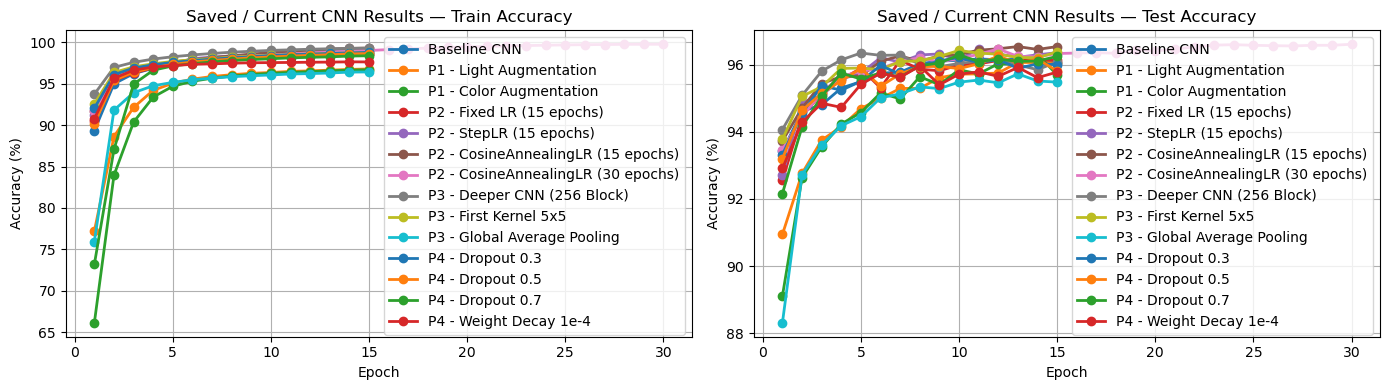

跳过已存在实验: Baseline CNN
跳过已存在实验: P1 - Light Augmentation
跳过已存在实验: P1 - Color Augmentation

Phase 1 - Data Augmentation 汇总结果


,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
1,P1 - Light Augmentation,15,0.1189,96.80%,96.07%,0.74%,1147914,light,none,0.5,0.0,"(32, 64, 128)",3,False
0,Baseline CNN,15,0.0482,98.65%,96.06%,2.59%,1147914,none,none,0.5,0.0,"(32, 64, 128)",3,False
2,P1 - Color Augmentation,15,0.1214,96.70%,95.69%,1.01%,1147914,color,none,0.5,0.0,"(32, 64, 128)",3,False


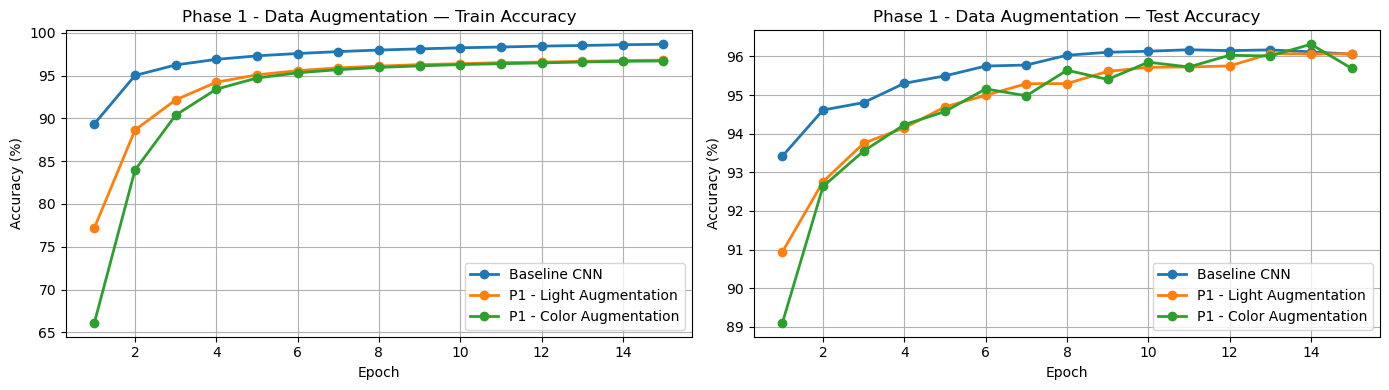

['Baseline CNN', 'P1 - Light Augmentation', 'P1 - Color Augmentation']

In [8]:
summary_df = summarize_results()

if not summary_df.empty:
    display(summary_df)
    plot_accuracy_comparison(ablation_results.keys(), title_prefix="Saved / Current CNN Results")
else:
    print("当前没有可绘制的实验结果。")
    print("你可以先确认 saved_models/training_history.pkl 是否存在，或直接运行 run_phase_1()。")

# 推荐执行顺序：
run_phase_1() 
#
# 如果 Phase 1 中某个结果最好，例如 P1 - Color Augmentation：
# BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P1 - Color Augmentation"]["config"])
# 重新运行上一单元后，再执行：
# run_phase_2()
#
# 如果 Phase 2 中某个结果最好，再把对应 config 写回 BEST_SO_FAR_CONFIG，
# 重新运行上一单元后继续：
# run_phase_3()
# run_phase_4()

跳过已存在实验: P2 - Fixed LR (15 epochs)
跳过已存在实验: P2 - StepLR (15 epochs)
跳过已存在实验: P2 - CosineAnnealingLR (15 epochs)
跳过已存在实验: P2 - CosineAnnealingLR (30 epochs)

Phase 2 - LR Scheduling 汇总结果


,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
3,P2 - CosineAnnealingLR (30 epochs),30,0.0069,99.78%,96.61%,3.17%,1147914,none,cosine,0.5,0.0,"(32, 64, 128)",3,False
2,P2 - CosineAnnealingLR (15 epochs),15,0.0257,99.33%,96.54%,2.78%,1147914,none,cosine,0.5,0.0,"(32, 64, 128)",3,False
1,P2 - StepLR (15 epochs),15,0.0319,99.12%,96.36%,2.76%,1147914,none,step,0.5,0.0,"(32, 64, 128)",3,False
0,P2 - Fixed LR (15 epochs),15,0.0492,98.60%,96.13%,2.47%,1147914,none,none,0.5,0.0,"(32, 64, 128)",3,False


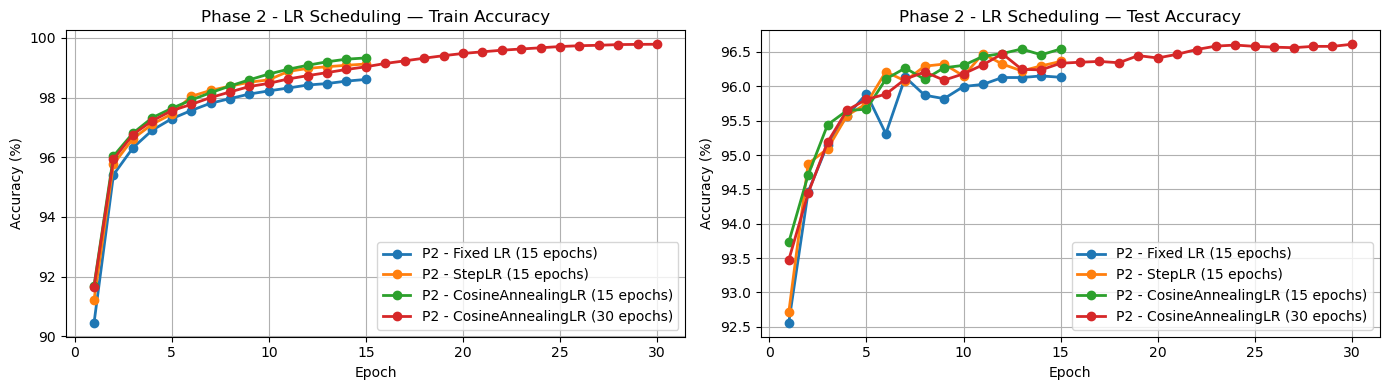

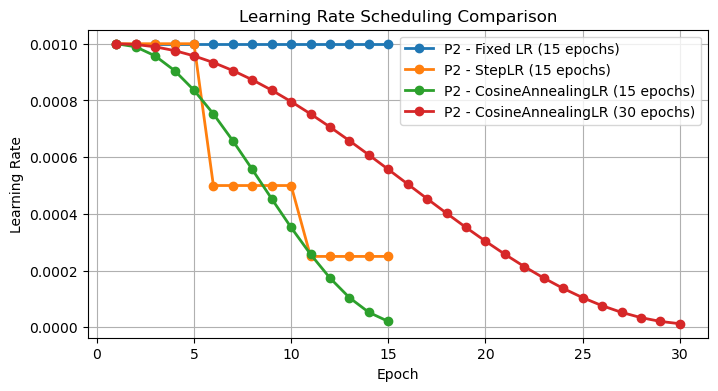

['P2 - Fixed LR (15 epochs)',
 'P2 - StepLR (15 epochs)',
 'P2 - CosineAnnealingLR (15 epochs)',
 'P2 - CosineAnnealingLR (30 epochs)']

In [9]:
## 如果 Phase 1 中某个结果最好，例如 P1 - Color Augmentation：
# BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P1 - Color Augmentation"]["config"])
 

BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P1 - Light Augmentation"]["config"])
# 重新运行上一单元后，再执行：
run_phase_2()

# 如果 Phase 2 中某个结果最好，再把对应 config 写回 BEST_SO_FAR_CONFIG，
# 重新运行上一单元后继续：
# run_phase_3()
# run_phase_4()

跳过已存在实验: P3 - Deeper CNN (256 Block)
跳过已存在实验: P3 - First Kernel 5x5
跳过已存在实验: P3 - Global Average Pooling

Phase 3 - Architecture Tweaks 汇总结果


,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
1,P3 - First Kernel 5x5,15,0.0423,98.81%,96.39%,2.43%,1149450,none,none,0.5,0.0,"(32, 64, 128)",5,False
0,P3 - Deeper CNN (256 Block),15,0.0216,99.32%,96.09%,3.24%,919306,none,none,0.5,0.0,"(32, 64, 128, 256)",3,False
2,P3 - Global Average Pooling,15,0.1275,96.44%,95.48%,0.96%,94986,none,none,0.5,0.0,"(32, 64, 128)",3,True


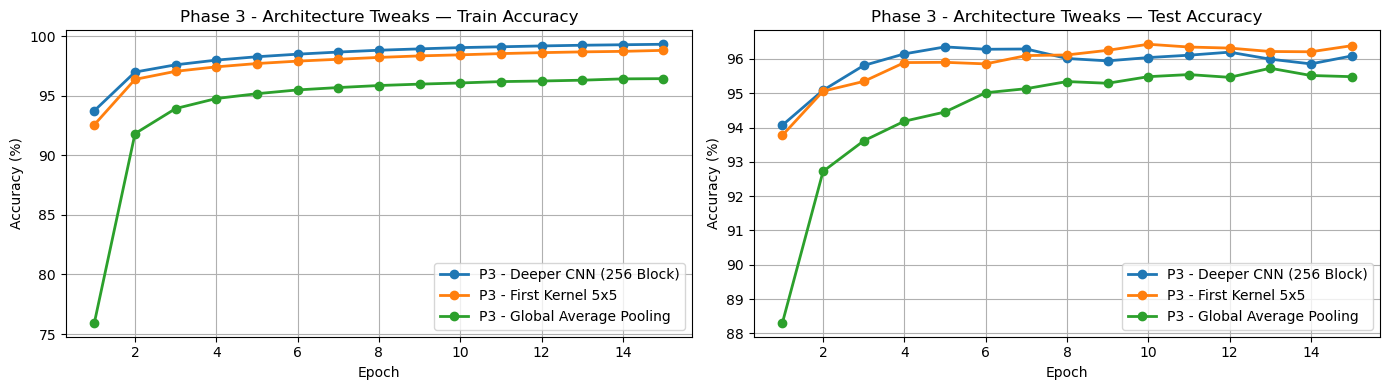

['P3 - Deeper CNN (256 Block)',
 'P3 - First Kernel 5x5',
 'P3 - Global Average Pooling']

In [10]:
# ---------- 阶段衔接（按需取消注释执行）----------
# Phase 2 已跑完且表中 Cosine 30 测试集最高时，进入 Phase 3 请按顺序做：
#
# 1) 在「上一大格」里找到 BEST_SO_FAR_CONFIG = copy.deepcopy(BASELINE_CONFIG)，
#    改成下面二选一（或改成你表里最优的那一行实验名）：
BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P2 - CosineAnnealingLR (30 epochs)"]["config"])
# BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P2 - CosineAnnealingLR (15 epochs)"]["config"])
#
# 2) 重新运行「上一大格」整格（让 PHASE_3_EXPERIMENTS 用新基线重建）
#
# 3) 在本格执行：
run_phase_3()

跳过已存在实验: P4 - Dropout 0.3
跳过已存在实验: P4 - Dropout 0.5
跳过已存在实验: P4 - Dropout 0.7
跳过已存在实验: P4 - Weight Decay 1e-4

Phase 4 - Regularization 汇总结果


,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
2,P4 - Dropout 0.7,15,0.0601,98.40%,96.25%,2.14%,1147914,none,none,0.7,0.0000,"(32, 64, 128)",3,False
0,P4 - Dropout 0.3,15,0.0412,98.81%,96.00%,2.80%,1147914,none,none,0.3,0.0000,"(32, 64, 128)",3,False
1,P4 - Dropout 0.5,15,0.0474,98.66%,95.81%,2.85%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
3,P4 - Weight Decay 1e-4,15,0.0867,97.65%,95.78%,1.87%,1147914,none,none,0.5,0.0001,"(32, 64, 128)",3,False


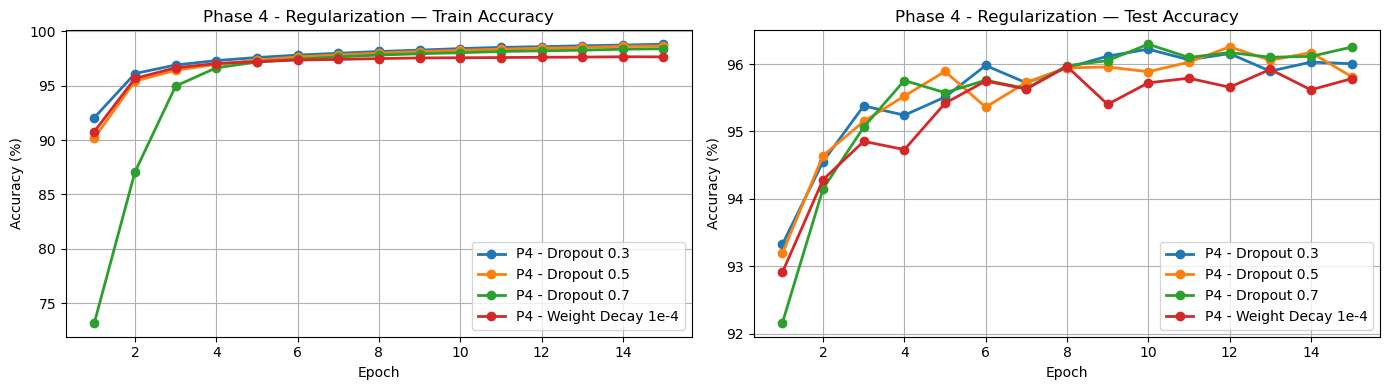

['P4 - Dropout 0.3',
 'P4 - Dropout 0.5',
 'P4 - Dropout 0.7',
 'P4 - Weight Decay 1e-4']

In [11]:

BEST_SO_FAR_CONFIG = copy.deepcopy(ablation_results["P3 - First Kernel 5x5"]["config"])
run_phase_4()

,Experiment,Epochs,Final Train Loss,Final Train Acc,Final Test Acc,Train-Test Gap,Params,Aug,Scheduler,Dropout,Weight Decay,Channels,First Kernel,GAP
6,P2 - CosineAnnealingLR (30 epochs),30,0.0069,99.78%,96.61%,3.17%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
5,P2 - CosineAnnealingLR (15 epochs),15,0.0257,99.33%,96.54%,2.78%,1147914,none,cosine,0.5,0.0000,"(32, 64, 128)",3,False
8,P3 - First Kernel 5x5,15,0.0423,98.81%,96.39%,2.43%,1149450,none,none,0.5,0.0000,"(32, 64, 128)",5,False
4,P2 - StepLR (15 epochs),15,0.0319,99.12%,96.36%,2.76%,1147914,none,step,0.5,0.0000,"(32, 64, 128)",3,False
12,P4 - Dropout 0.7,15,0.0601,98.40%,96.25%,2.14%,1147914,none,none,0.7,0.0000,"(32, 64, 128)",3,False
3,P2 - Fixed LR (15 epochs),15,0.0492,98.60%,96.13%,2.47%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
7,P3 - Deeper CNN (256 Block),15,0.0216,99.32%,96.09%,3.24%,919306,none,none,0.5,0.0000,"(32, 64, 128, 256)",3,False
1,P1 - Light Augmentation,15,0.1189,96.80%,96.07%,0.74%,1147914,light,none,0.5,0.0000,"(32, 64, 128)",3,False
0,Baseline CNN,15,0.0482,98.65%,96.06%,2.59%,1147914,none,none,0.5,0.0000,"(32, 64, 128)",3,False
10,P4 - Dropout 0.3,15,0.0412,98.81%,96.00%,2.80%,1147914,none,none,0.3,0.0000,"(32, 64, 128)",3,False


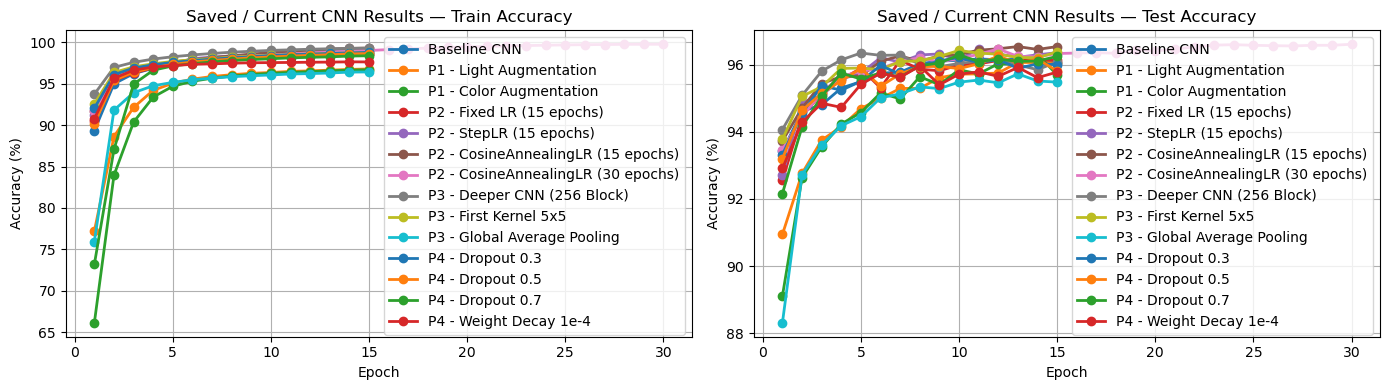

In [12]:
summary_df = summarize_results()

if not summary_df.empty:
    display(summary_df)
    plot_accuracy_comparison(ablation_results.keys(), title_prefix="Saved / Current CNN Results")
else:
    print("当前没有可绘制的实验结果。")
    print("你可以先确认 saved_models/training_history.pkl 是否存在，或直接运行 run_phase_1()。")